In [2]:
from pathlib import Path
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.utils import evaluate_finetuned_model, get_pretrained_model_url
from sklearn.metrics import r2_score

def plot_predicted_vs_true(y_true, y_pred, ax, title):
    ax.scatter(y_true, y_pred)
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax.set_xlabel("True Yield kg/H")
    ax.set_ylabel("Predicted Yield kg/H")
    ax.set_title(title)

In [3]:
data_folder = Path.cwd().parent / "data/datasets"
composite_window = "month"
unique_id_column = "Field_ID"
target_column = 'Yield kg/H'

In [4]:
extractions = pd.read_parquet(data_folder/"ghana_maize_multiyear_extractions.parquet")
train_df, val_df, test_df = extractions[extractions["dataset"] == "train"], extractions[extractions["dataset"] == "val"], extractions[extractions["dataset"] == "test"]

#### Data investigation

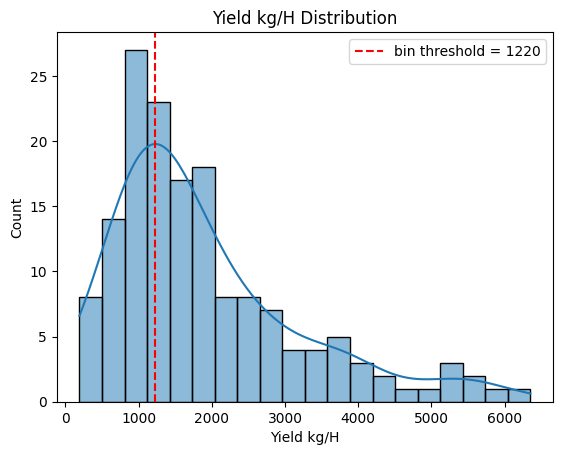

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
bin_th = 1220
sns.histplot(extractions[target_column], bins=20, kde=True)
plt.axvline(bin_th, color='red', linestyle='--', label=f"bin threshold = {str(bin_th)}")
plt.title('Yield kg/H Distribution')
plt.legend()
plt.show()

##### Random Forest

In [6]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [7]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [8]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

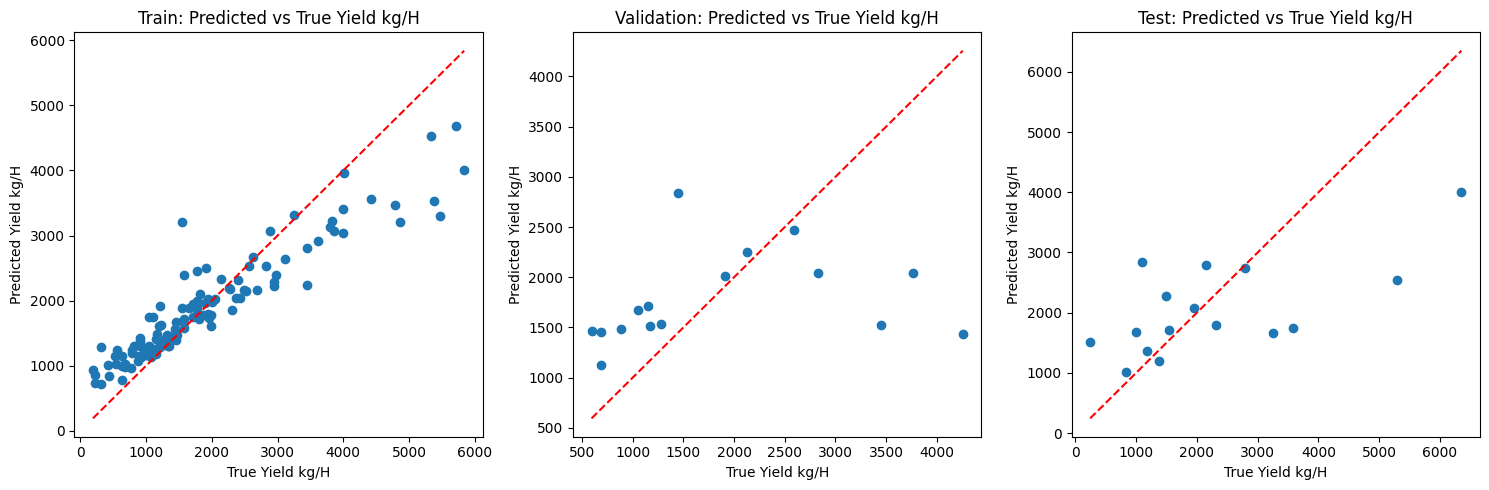

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline


rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestRegressor(
        n_estimators=50,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ))
])

rf_pipe.fit(X_train, y_train)

preds_train_rf = rf_pipe.predict(X_train)
preds_val_rf = rf_pipe.predict(X_val)
preds_test_rf = rf_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train_rf, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val_rf, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test_rf, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Catboost 

0:	learn: 1252.9198235	total: 3.41ms	remaining: 1.7s
499:	learn: 572.5404665	total: 865ms	remaining: 0us


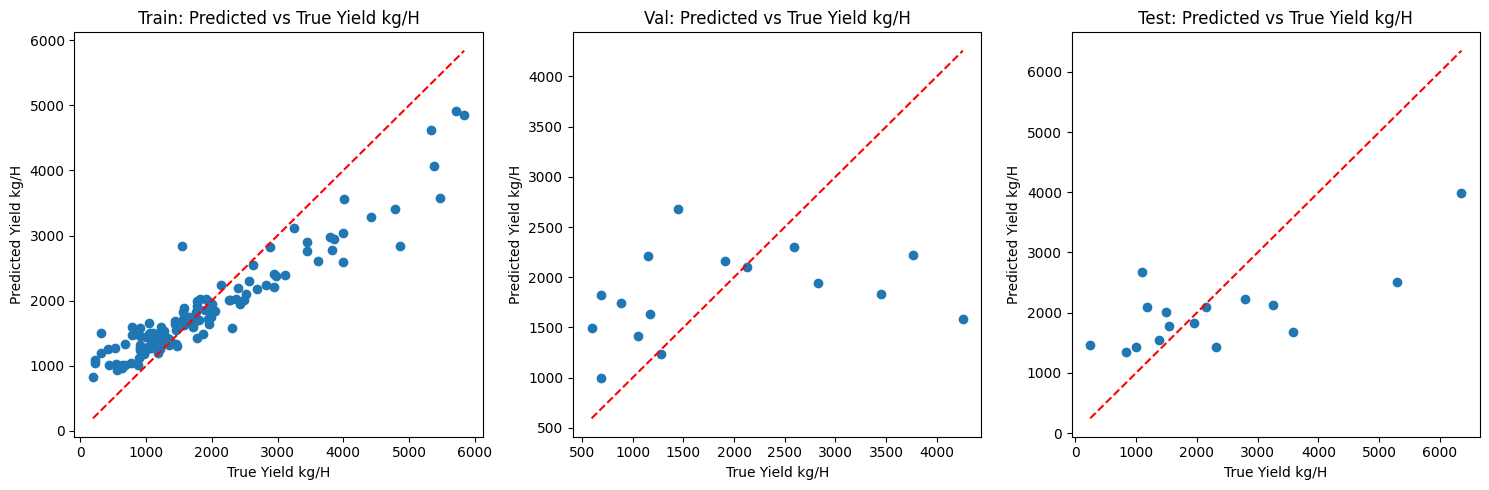

In [12]:
from catboost import CatBoostRegressor
cat_reg = CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose = 500
)

cat_reg.fit(X_train, y_train,
)

preds_train_cb = cat_reg.predict(X_train) 
preds_val_cb = cat_reg.predict(X_val)
preds_test_cb = cat_reg.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(y_train, preds_train_cb, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_val, preds_val_cb, axes[1], "Val: Predicted vs True Yield kg/H")
plot_predicted_vs_true(y_test, preds_test_cb, axes[2], "Test: Predicted vs True Yield kg/H")

plt.tight_layout()
plt.show()

##### Presto

In [13]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
task_type = "regression"
target_name="Yield kg/H"
target_mean = train_df[target_name].mean()
target_std = train_df[target_name].std()   

In [14]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

In [15]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path(".").cwd().parent / "models"
experiment_name = f"presto-geomaize-ft-{composite_window}-regression"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32 
num_workers = 0
max_epochs = 150  # Keep reasonable number of epochs
patience = 150  # More patience for convergence
learning_rate = 1e-3
# freeze_layers = ['encoder']

In [16]:
def finetune_presto(
    train_ds,
    val_ds,
    composite_window,
    num_outputs,
    experiment_name,
    model_output_dir,
    learning_rate=1e-3,
    max_epochs=100,
    batch_size=32,
    patience=10,
    num_workers=0,
):
    loss_fn = nn.MSELoss()
    pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
    try:
        model = PretrainedPrestoWrapper(
            num_outputs=num_outputs,
            regression=True,
        )
        model = load_presto_weights(model, pretrained_model_path, strict=False)
    except:
        model = PretrainedPrestoWrapper(
            num_outputs=num_outputs,
            regression=True,
            pretrained_model_path=pretrained_model_path,
        )

    parameters = param_groups_lrd(model)
    optimizer = AdamW(parameters, lr=learning_rate)

    hyperparams = Hyperparams(
        max_epochs=max_epochs,
        batch_size=batch_size,
        patience=patience,
        num_workers=num_workers,
        lr=learning_rate,
    )

    scheduler = lr_scheduler.ConstantLR(optimizer, factor=1.0)
    # scheduler_plateau = lr_scheduler.ReduceLROnPlateau(optimizer, factor=drop_factor, min_lr=end_lr)
    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )
    val_dl = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=collate_fn,
    )

    finetuned_model = finetune.run_finetuning(
        model=model,
        train_dl=train_dl,
        val_dl=val_dl,
        experiment_name=experiment_name,
        output_dir=model_output_dir,
        loss_fn=loss_fn,
        optimizer=optimizer,
        scheduler=scheduler,
        hyperparams=hyperparams,
        setup_logging=False,  # Already setup logging
    )
    return finetuned_model

In [18]:
finetuned_model = finetune_presto(
    train_ds=train_ds,
    val_ds=val_ds,    
    composite_window=composite_window,
    num_outputs=num_outputs,
    experiment_name=experiment_name,
    model_output_dir=model_output_dir,
    learning_rate=learning_rate,
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers
)

2026-04-01 17:03:15.051 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/git/GEOMaize/models/presto-geomaize-ft-month-regression


Finetuning:   0%|          | 0/150 [00:00<?, ?it/s]

Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-04-01 17:03:15.364 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/150: Epoch 1/150 | Train Loss: 1.2226 | Val Loss: 1.0792 | Best Loss: 1.0792 (improved)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

...

2026-04-01 17:03:53.379 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 148/150: Epoch 148/150 | Train Loss: 0.3710 | Val Loss: 1.0446 | Best Loss: 0.6267 (no improvement for 1 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-04-01 17:03:53.577 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 149/150: Epoch 149/150 | Train Loss: 0.3380 | Val Loss: 1.2080 | Best Loss: 0.6267 (no improvement for 2 epochs)


Training:   0%|          | 0/4 [00:00<?, ?it/s]

2026-04-01 17:03:53.942 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 150/150: Epoch 150/150 | Train Loss: 0.3789 | Val Loss: 0.8454 | Best Loss: 0.6267 (no improvement for 3 epochs)
2026-04-01 17:03:54.058 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


2026-04-01 17:03:54.146 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on regression task
2026-04-01 17:03:54.282 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on regression task
2026-04-01 17:03:54.307 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:117 - Evaluating the finetuned model on regression task


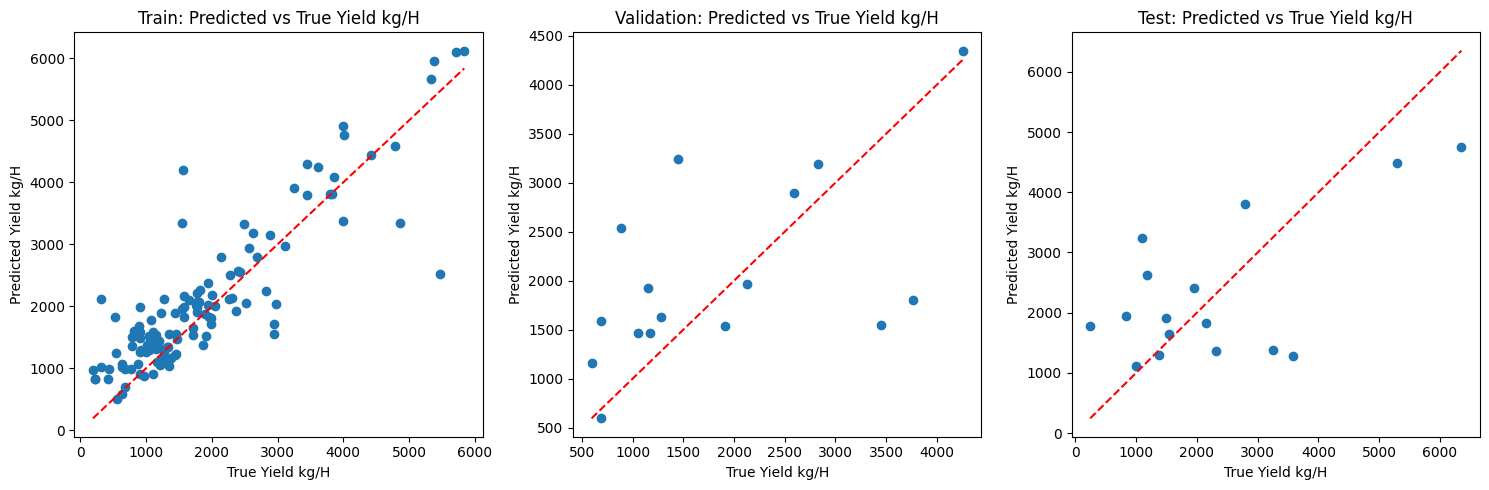

In [19]:
# Get predictions for train and validation sets as well
train_metrics_presto, train_preds_presto, train_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics_presto, val_preds_presto, val_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

test_metrics_presto, test_preds_presto, test_targets_presto = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(train_targets_presto, train_preds_presto, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(val_targets_presto, val_preds_presto, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(test_targets_presto, test_preds_presto, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

##### Presto + Catboost 

0:	learn: 0.9929556	total: 7.01ms	remaining: 3.5s
499:	learn: 0.4533528	total: 1.6s	remaining: 0us


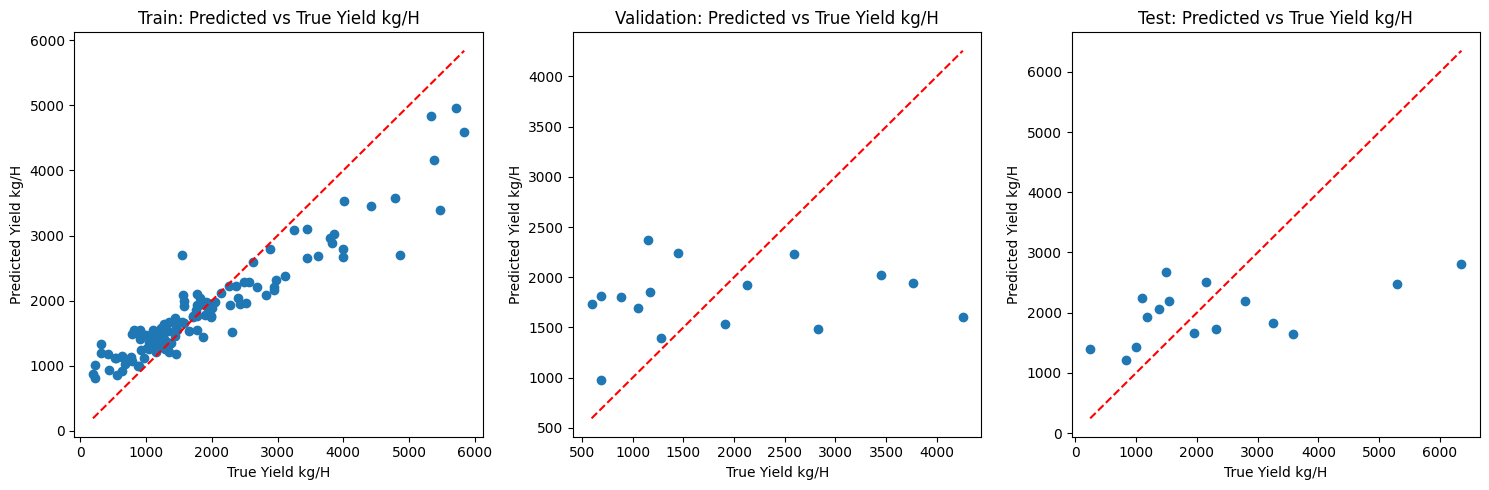

In [20]:
from scaleagdata_vito.presto.utils import get_encodings

model = PretrainedPrestoWrapper(
    num_outputs=num_outputs,
    regression=True,
    pretrained_model_path=get_pretrained_model_url(composite_window=composite_window),
)

from torch.utils.data import DataLoader

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("cat", CatBoostRegressor(
        iterations=500,
        learning_rate=0.01,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=500
    ))
])

cat_enc_pipe.fit(all_encodings, all_targets)

preds_train_cbp = train_ds.revert_to_original_units(cat_enc_pipe.predict(all_encodings))
preds_val_cbp = val_ds.revert_to_original_units(cat_enc_pipe.predict(all_encodings_val))
preds_test_cbp = test_ds.revert_to_original_units(cat_enc_pipe.predict(all_encodings_test))
all_targets_cbp = train_ds.revert_to_original_units(all_targets)
all_targets_val_cbp = val_ds.revert_to_original_units(all_targets_val)
all_targets_test_cbp = test_ds.revert_to_original_units(all_targets_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plot_predicted_vs_true(all_targets_cbp, preds_train_cbp, axes[0], "Train: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_val_cbp, preds_val_cbp, axes[1], "Validation: Predicted vs True Yield kg/H")
plot_predicted_vs_true(all_targets_test_cbp, preds_test_cbp, axes[2], "Test: Predicted vs True Yield kg/H")
plt.tight_layout()
plt.show()

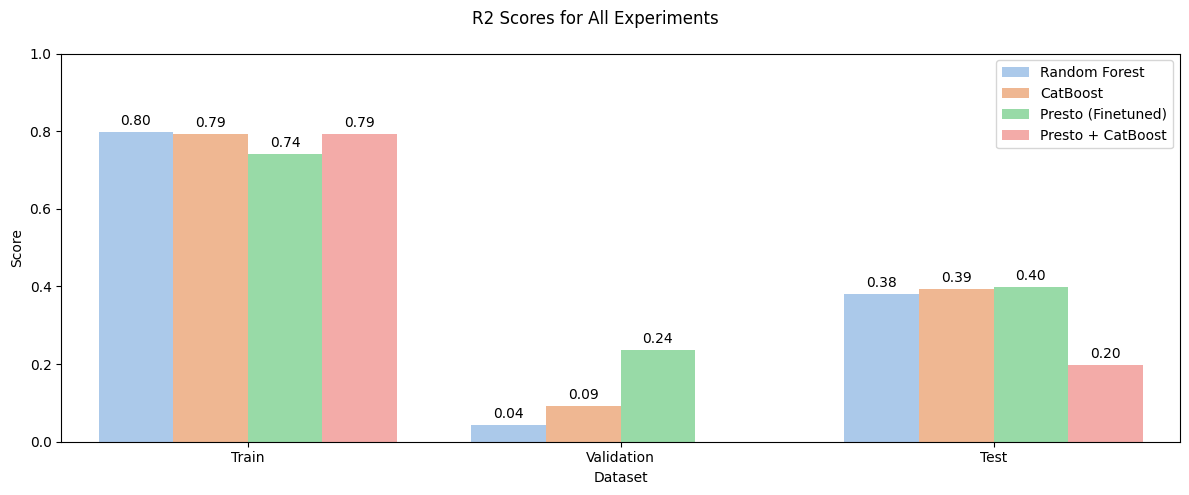

In [29]:
# Combine R2 scores from all models for all datasets
r2_results = pd.DataFrame({
    'Dataset': ['Train', 'Validation', 'Test'],
    'Random Forest': [rf_pipe.score(X_train, y_train), rf_pipe.score(X_val, y_val), rf_pipe.score(X_test, y_test)],
    'CatBoost': [cat_reg.score(X_train, y_train), cat_reg.score(X_val, y_val), cat_reg.score(X_test, y_test)],
    'Presto (Finetuned)': [train_metrics_presto['R2_score'], val_metrics_presto['R2_score'], test_metrics_presto['R2_score']],
    'Presto + CatBoost': [cat_enc_pipe.score(all_encodings, all_targets), cat_enc_pipe.score(all_encodings_val, all_targets_val), cat_enc_pipe.score(all_encodings_test, all_targets_test)]
})

# Melt to long format for seaborn
r2_melted = r2_results.melt(id_vars='Dataset', var_name='Experiment', value_name='R2 Score')

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

sns.barplot(
    data=r2_melted,
    x="Dataset",
    y="R2 Score",
    hue="Experiment",
    ax=ax,
    palette="pastel"
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.legend(loc="upper right")

# Add numbers on top of each bar
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        ax.annotate(f"{height:.2f}", 
                    (p.get_x() + p.get_width() / 2., height + 0.01), 
                    ha='center', va='bottom', fontsize=10, color='black', rotation=0)

plt.suptitle("R2 Scores for All Experiments")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()